In [1]:
import torch
import numpy
import matplotlib.pyplot as plt
import dflat

import torch
import os
import numpy as np
from scipy.ndimage import zoom
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

from dflat.initialize import focusing_lens, multiplexing_mask_orthrand
from dflat.metasurface import reverse_lookup_optimize, load_optical_model
from dflat.plot_utilities import format_plot
from dflat.propagation import PointSpreadFunction
from dflat.render import hsi_to_rgb

out_name = "./temp/"
if not os.path.exists(out_name):
    os.mkdir(out_name)

(4, 1001, 1001) (4, 1001, 1001)


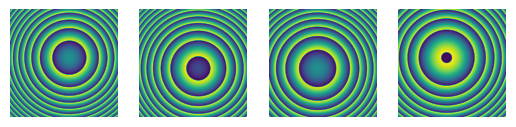

In [3]:
# computation of four focusing lens phase profiles, each for a particular wavelength
in_size = [1001, 1001]
in_dx_m=[4*250e-9, 4*250e-9] #--> 4x4 set of unit cell
#in_size = [1001, 1001]
#in_dx_m = [4*250e-9, 4*250e-9]
# unit cell 250
out_distance = 50e-3

#  ,532e-9,
wavelength_set_m = np.array([500e-9, 550e-9, 600e-9, 650e-9])
#wavelength_set_m = np.array([488e-9, 532e-9, 633e-9, 658e-9])

dx = 50e-6
offsets = [[-dx, dx], [dx, dx], [dx, -dx], [-dx, -dx]]
depth_set_m = [10 for i in range(len(wavelength_set_m))]

amp, phase, aperture = focusing_lens(
    in_size,
    in_dx_m,
    wavelength_set_m,
    depth_set_m,
    offsets,
    out_distance,
    aperture_radius_m=None,
    radial_symmetry=False,
)
print(amp.shape, phase.shape)

fig, ax = plt.subplots(1,4)
for i in range(4):
    ax[i].imshow(phase[i])
    ax[i].set_axis_off()

In [18]:
# nanocylinders library

load_prev = False
prev_save = out_name + 'lens_lookup.pickle'

fb = [15e-9, 110e-9]
pmin = (30e-9 - fb[0])/(fb[1]-fb[0])
pmax = (100e-9 - fb[0])/(fb[1]-fb[0])
pbounds = [pmin, pmax]
#pbounds = [0.0, 1.0]
param, shape, err = reverse_lookup_optimize(
    amp[i:i+1, None, None],
    phase[i:i+1,None, None],
    wavelength_set_m[i:i+1],
    "Nanocylinders_TiO2_U250H600",
    lr=5e-2,
    max_iter=100,
    opt_phase_only=False,
    batch_size=None,
    pbounds=pbounds
)


if load_prev and os.path.exists(prev_save):
    with open(prev_save,'rb') as handle:
        data = pickle.load(handle)
        shapes = data["shapes"]
else:
    list_shapes = []
    list_params = []
    for i in range(amp.shape[0]):
        param, shape, err = reverse_lookup_optimize(
            amp[i:i+1, None, None],
            phase[i:i+1,None, None],
            wavelength_set_m[i:i+1],
            "Nanocylinders_TiO2_U250H600",
            lr=5e-2,
            max_iter=100,
            opt_phase_only=False,
            batch_size=None,
            pbounds=pbounds
        )
        print(shape.min(), shape.max())
        print(param.min(), param.max())
        list_shapes.append(shape)
        list_params.append(param)
    shapes = np.concatenate(list_shapes, axis=0)
    params = np.concatenate(list_params, axis=0)

    data = {"shapes": shapes, "params": params}

print(shapes.min(), shapes.max())

with open(out_name + 'lens_lookup.pickle', 'wb') as handle:
    pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)


import pickle
file_path = 'data.pickle'
with open(file_path, 'wb') as file:
    pickle.dump(shapes, file)

[0, 1]
Running optimization with device cuda
Target Module: dflat.metasurface.optical_model.NeuralCells
Note: trainable_model key in NeuralCells is deprecated. Model will be set to requires_grad.
Target Module: dflat.metasurface.nn_siren.SirenNet
Target: dflat.metasurface.optical_model.NeuralCells Loading from checkpoint DFlat/Models/Nanocylinders_TiO2_U250H600/model.ckpt as strict=True
Restored dflat.metasurface.optical_model.NeuralCells with 0 missing and 0 unexpected keys


Loss: 0.1591: 100%|██████████| 100/100 [00:10<00:00,  9.71it/s][A


2.0535492e-08 8.593113e-08
0.058268335 0.7466435
Running optimization with device cuda
Target Module: dflat.metasurface.optical_model.NeuralCells
Note: trainable_model key in NeuralCells is deprecated. Model will be set to requires_grad.
Target Module: dflat.metasurface.nn_siren.SirenNet
Target: dflat.metasurface.optical_model.NeuralCells Loading from checkpoint DFlat/Models/Nanocylinders_TiO2_U250H600/model.ckpt as strict=True
Restored dflat.metasurface.optical_model.NeuralCells with 0 missing and 0 unexpected keys


KeyboardInterrupt: 